In [109]:
import os
import pandas as pd 
import matplotlib.pyplot as plt
import tsfel
import time
import numpy as np

In [110]:
nSet = 0
fileTS = os.path.join(os.getcwd(), "pdfTimeSeries{:d}.pkl".format(nSet))
pdfTS = pd.read_pickle(fileTS)

In [111]:
pdfTS

,u,y,i,e
0,0.000000,-0.076287,9N6FK96G8,-0.076287
1,0.000000,0.019506,9N6FK96G8,0.019506
2,0.000000,-0.073928,9N6FK96G8,-0.073928
3,0.000000,0.044727,9N6FK96G8,0.044727
4,0.000000,-0.010317,9N6FK96G8,-0.010317
...,...,...,...,...
718,-0.465181,-0.449052,UMTMULQVC,0.016130
719,-0.465181,-0.417802,UMTMULQVC,0.047379
720,-0.465181,-0.510018,UMTMULQVC,-0.044837
721,-0.465181,-0.507332,UMTMULQVC,-0.042151


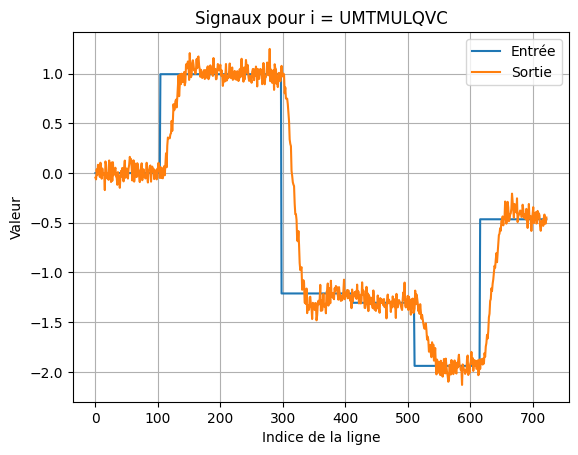

In [112]:
identifiant = "UMTMULQVC"

pdfTS_filtre = pdfTS[pdfTS["i"] == identifiant]

pdfTS_filtre["u"].plot(label="Entrée")
pdfTS_filtre["y"].plot(label="Sortie")


plt.xlabel("Indice de la ligne")
plt.ylabel("Valeur")
plt.title(f"Signaux pour i = {identifiant}")
plt.grid()
plt.legend()
plt.show()

In [113]:
fileEF = os.path.join(os.getcwd(), "pdfFeatures{:d}.pkl".format(nSet))
pdfEF = pd.read_pickle(fileEF)

In [114]:
pdfEF

,e_Absolute energy,e_Area under the curve,e_Autocorrelation,e_Average power,e_Centroid,e_ECDF Percentile Count_0,e_ECDF Percentile Count_1,e_ECDF Percentile_0,e_ECDF Percentile_1,e_ECDF_0,...,y_Wavelet variance_1,y_Wavelet variance_2,y_Wavelet variance_3,y_Wavelet variance_4,y_Wavelet variance_5,y_Wavelet variance_6,y_Wavelet variance_7,y_Wavelet variance_8,y_Zero crossing rate,i
0,0.030425,0.057124,1.0,0.016903,0.799343,2.0,8.0,-0.073928,0.044727,0.1,...,0.004341,0.003173,0.001785,0.00109,0.000761,0.00059,0.000489,0.000423,6.0,9N6FK96G8
1,0.034108,0.071956,2.0,0.018949,0.870813,2.0,8.0,-0.068527,0.031442,0.1,...,0.003611,0.003788,0.003008,0.002341,0.001897,0.001597,0.001382,0.001221,4.0,9N6FK96G8
2,0.042274,0.083902,1.0,0.023486,0.962404,2.0,8.0,-0.105961,0.016858,0.1,...,0.001518,0.000854,0.000852,0.000831,0.000794,0.000749,0.000702,0.000656,4.0,9N6FK96G8
3,0.033578,0.080128,2.0,0.018654,0.551002,2.0,8.0,-0.104259,0.021024,0.1,...,0.007749,0.006425,0.00425,0.003015,0.002334,0.001921,0.001645,0.001445,3.0,9N6FK96G8
4,0.023003,0.049324,1.0,0.012779,1.067663,2.0,8.0,-0.015203,0.035602,0.1,...,0.0012,0.001165,0.000987,0.000811,0.000682,0.00059,0.00052,0.000465,4.0,9N6FK96G8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49311,0.058049,0.090205,1.0,0.032249,0.799835,2.0,8.0,-0.087101,0.032083,0.1,...,0.031444,0.015267,0.019952,0.027048,0.031054,0.032461,0.032345,0.031438,0.0,UMTMULQVC
49312,0.035514,0.066874,1.0,0.01973,0.918799,2.0,8.0,-0.038623,0.032083,0.1,...,0.017774,0.017436,0.023716,0.028415,0.030289,0.030336,0.02944,0.028123,0.0,UMTMULQVC
49313,0.035254,0.063878,1.0,0.019586,0.700099,2.0,8.0,-0.038623,0.070625,0.1,...,0.012935,0.018426,0.027143,0.031986,0.033404,0.032951,0.031636,0.029988,0.0,UMTMULQVC
49314,0.041431,0.080162,1.0,0.023017,1.048823,2.0,8.0,-0.073158,0.060267,0.1,...,0.032227,0.018178,0.02272,0.029591,0.033423,0.034674,0.034409,0.033364,0.0,UMTMULQVC


***DATA PREP***

Step 1,2,3 : Cleaning, scaling and spliting data

In [115]:
import numpy as np
import pandas as pd

# Copie du dataframe de features
df = pdfEF.copy()

# On enlève l'identifiant des features si la colonne existe
X = df.drop(columns=["i"], errors="ignore")

# Conversion en numérique
X = X.apply(pd.to_numeric, errors="coerce")

# Remplacement des valeurs infinies
X = X.replace([np.inf, -np.inf], np.nan)

# Suppression des colonnes complètement vides
X = X.dropna(axis=1, how="all")

# Remplacement des valeurs manquantes par la médiane
X = X.fillna(X.median())

# Suppression des colonnes constantes
X = X.loc[:, X.nunique(dropna=True) > 1]

print("Shape après cleaning :", X.shape)

Shape après cleaning : (49316, 246)


Split

In [116]:
from sklearn.model_selection import train_test_split

# Indices pour retrouver les lignes originales après le split
indices = np.arange(X.shape[0])

X_train, X_test, idx_train, idx_test = train_test_split(
    X,
    indices,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

X_train : (39452, 246)
X_test : (9864, 246)


Scaling

In [117]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling terminé")

Scaling terminé


In [118]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.7, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Nombre de features au départ :", X.shape[1])
print("Nombre de composantes PCA gardées :", X_train_pca.shape[1])
print("Variance expliquée :", round(pca.explained_variance_ratio_.sum(), 4))

Nombre de features au départ : 246
Nombre de composantes PCA gardées : 14
Variance expliquée : 0.7042


**Kernel Density Estimation**

In [119]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity
import time

t0 = time.time()

# Split du train PCA en :
# - une partie pour entraîner la KDE
# - une partie pour définir le seuil de vraisemblance
X_kde_train, X_kde_val = train_test_split(
    X_train_pca,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

# Échantillon pour accélérer la KDE
n_sample = min(3000, len(X_kde_train))

sample_idx = np.random.choice(
    len(X_kde_train),
    size=n_sample,
    replace=False
)

X_kde_sample = X_kde_train[sample_idx]

print("Taille utilisée pour KDE :", X_kde_sample.shape)

# Intervalle borné de recherche du bandwidth
bandwidth_min = 0.1
bandwidth_max = 2.0
nb_tests = 10

bandwidth_values = np.linspace(
    bandwidth_min,
    bandwidth_max,
    nb_tests
)

params = {
    "bandwidth": bandwidth_values
}

# Recherche du meilleur bandwidth
grid = GridSearchCV(
    KernelDensity(kernel="gaussian"),
    params,
    cv=3
)

grid.fit(X_kde_sample)

best_bandwidth = grid.best_params_["bandwidth"]

print("Meilleur bandwidth trouvé :", best_bandwidth)

# KDE final avec le meilleur bandwidth
kde = KernelDensity(
    kernel="gaussian",
    bandwidth=best_bandwidth
)

kde.fit(X_kde_sample)

print("Temps entraînement KDE :", round(time.time() - t0, 2), "secondes")

Taille utilisée pour KDE : (3000, 14)
Meilleur bandwidth trouvé : 1.1555555555555557
Temps entraînement KDE : 2.65 secondes


In [120]:
# Log-vraisemblance sur validation et test
val_log_likelihood = kde.score_samples(X_kde_val)
test_log_likelihood = kde.score_samples(X_test_pca)

# Seuil : les 20% avec la plus faible vraisemblance sont considérés comme points de bord
threshold = np.percentile(val_log_likelihood, 20)

# Détection sur le test
test_is_border = test_log_likelihood < threshold

print("Seuil de log-vraisemblance :", threshold)
print("Nombre de points test :", len(test_is_border))
print("Points sur les bords :", test_is_border.sum())
print("Pourcentage :", round(test_is_border.mean() * 100, 2), "%")

Seuil de log-vraisemblance : -29.488584812679335
Nombre de points test : 9864
Points sur les bords : 1939
Pourcentage : 19.66 %


In [121]:
df_test_result = df.iloc[idx_test].copy()

df_test_result["log_likelihood"] = test_log_likelihood
df_test_result["is_border"] = test_is_border

df_test_result[["log_likelihood", "is_border"]].head(20)

,log_likelihood,is_border
48186,-24.896616,False
38307,-24.817010,False
47752,-23.685594,False
44372,-24.645877,False
147,-27.156096,False
14174,-27.068348,False
28078,-88.714403,True
6095,-24.079096,False
37486,-24.611205,False
33555,-24.381746,False


In [122]:
df_test_result.sort_values("log_likelihood")[["log_likelihood", "is_border"]].head(20)

,log_likelihood,is_border
32640,-142.187591,True
28614,-132.831563,True
18237,-132.752339,True
38499,-130.312925,True
37565,-125.850191,True
38533,-124.299563,True
16030,-122.002624,True
17894,-94.550045,True
34973,-94.055490,True
29468,-90.103358,True


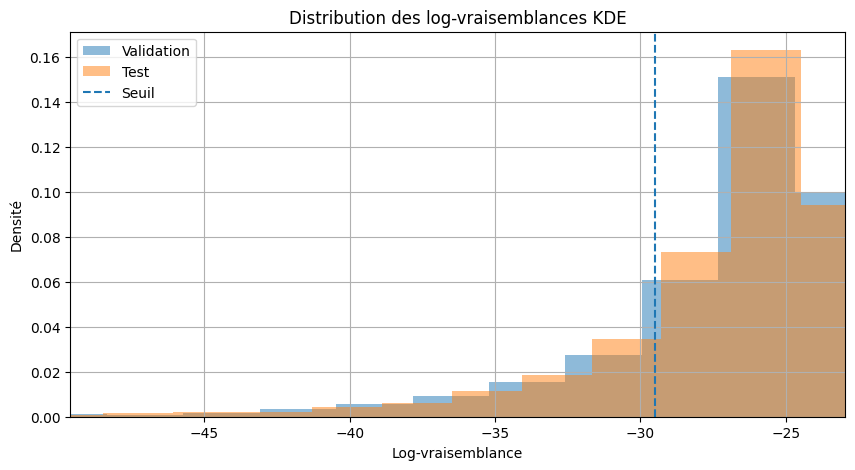

In [123]:
import matplotlib.pyplot as plt

all_scores = np.concatenate([val_log_likelihood, test_log_likelihood])

xmin = np.percentile(all_scores, 1)
xmax = np.percentile(all_scores, 99)

plt.figure(figsize=(10, 5))

plt.hist(
    val_log_likelihood,
    bins=50,
    density=True,
    alpha=0.5,
    label="Validation"
)

plt.hist(
    test_log_likelihood,
    bins=50,
    density=True,
    alpha=0.5,
    label="Test"
)

plt.axvline(
    threshold,
    linestyle="--",
    label="Seuil"
)

plt.xlim(xmin, xmax)

plt.xlabel("Log-vraisemblance")
plt.ylabel("Densité")
plt.title("Distribution des log-vraisemblances KDE")
plt.legend()
plt.grid()
plt.show()

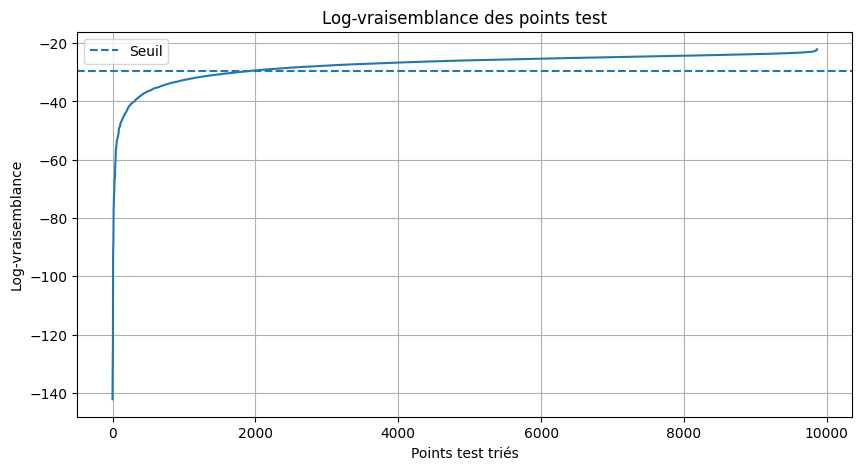

In [124]:
sorted_scores = np.sort(test_log_likelihood)

plt.figure(figsize=(10, 5))

plt.plot(sorted_scores)
plt.axhline(threshold, linestyle="--", label="Seuil")

plt.xlabel("Points test triés")
plt.ylabel("Log-vraisemblance")
plt.title("Log-vraisemblance des points test")
plt.legend()
plt.grid()
plt.show()

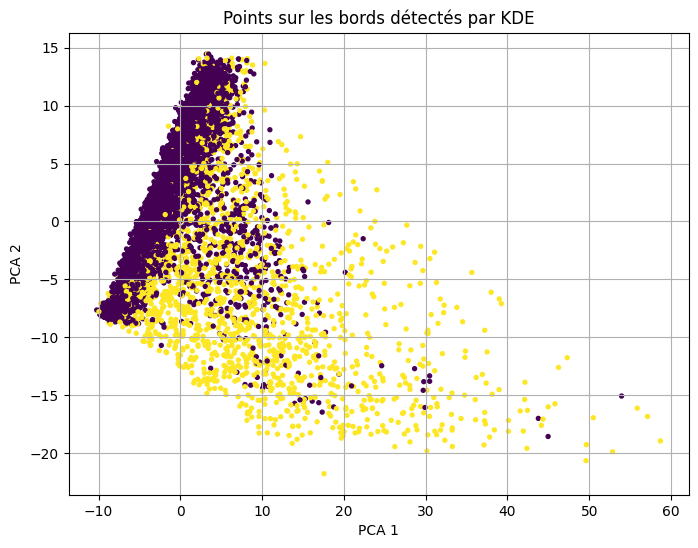

In [125]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=test_is_border,
    s=8
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Points sur les bords détectés par KDE")
plt.grid()
plt.show()

---
****Fichier avec défaut 1****
---

In [126]:
nSet = 0
fileTS_def = os.path.join(os.getcwd(), "pdfTimeSeries1.pkl".format(nSet))
pdfTS_def = pd.read_pickle(fileTS_def)

In [127]:
pdfTS_def

,u,y,i,e
0,0.000000,-0.178862,VJG2XDS11,-0.178862
1,0.000000,0.009132,VJG2XDS11,0.009132
2,0.000000,0.058681,VJG2XDS11,0.058681
3,0.000000,0.010686,VJG2XDS11,0.010686
4,0.000000,-0.001032,VJG2XDS11,-0.001032
...,...,...,...,...
1805,0.933992,0.924232,RJ9RSGP8N,-0.009760
1806,0.933992,1.047756,RJ9RSGP8N,0.113764
1807,0.933992,0.923011,RJ9RSGP8N,-0.010981
1808,0.933992,0.878074,RJ9RSGP8N,-0.055918


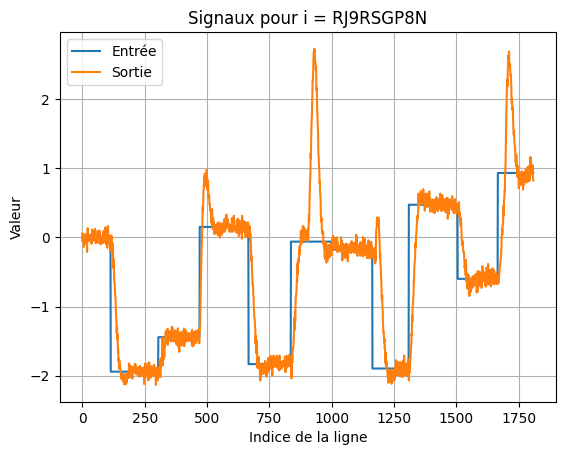

In [128]:
identifiant = "RJ9RSGP8N"

pdfTSdef_filtre = pdfTS_def[pdfTS_def["i"] == identifiant]

pdfTSdef_filtre["u"].plot(label="Entrée")
pdfTSdef_filtre["y"].plot(label="Sortie")

plt.xlabel("Indice de la ligne")
plt.ylabel("Valeur")
plt.title(f"Signaux pour i = {identifiant}")
plt.grid()
plt.legend()
plt.show()

In [129]:
fileEF_default = os.path.join(os.getcwd(), "pdfFeatures1.pkl".format(nSet))
pdfEF_default = pd.read_pickle(fileEF_default)

In [136]:
pdfEF_default

,e_Absolute energy,e_Area under the curve,e_Autocorrelation,e_Average power,e_Centroid,e_ECDF Percentile Count_0,e_ECDF Percentile Count_1,e_ECDF Percentile_0,e_ECDF Percentile_1,e_ECDF_0,...,y_Wavelet variance_1,y_Wavelet variance_2,y_Wavelet variance_3,y_Wavelet variance_4,y_Wavelet variance_5,y_Wavelet variance_6,y_Wavelet variance_7,y_Wavelet variance_8,y_Zero crossing rate,i
0,0.079972,0.070585,1.0,0.044429,0.743867,2.0,8.0,-0.16203,0.058681,0.1,...,0.006549,0.002512,0.000561,0.000079,0.000034,0.000084,0.000139,0.00018,7.0,VJG2XDS11
1,0.113216,0.108242,1.0,0.062898,1.067862,2.0,8.0,-0.16203,0.070568,0.1,...,0.012497,0.004955,0.001334,0.000357,0.000192,0.000225,0.000287,0.000336,5.0,VJG2XDS11
2,0.080514,0.102533,1.0,0.04473,0.673056,2.0,8.0,-0.071974,0.020168,0.1,...,0.00544,0.003927,0.002602,0.001843,0.001432,0.001188,0.001027,0.000911,3.0,VJG2XDS11
3,0.041541,0.086099,1.0,0.023078,0.947138,2.0,8.0,-0.089413,0.004123,0.1,...,0.000665,0.000911,0.000832,0.000722,0.000634,0.000565,0.000509,0.000463,4.0,VJG2XDS11
4,0.032314,0.046819,1.0,0.017952,0.264517,2.0,8.0,-0.089413,0.017185,0.1,...,0.002195,0.002557,0.002071,0.001648,0.001362,0.001164,0.001019,0.000907,6.0,VJG2XDS11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9978,0.043084,0.066947,1.0,0.023935,0.874975,2.0,8.0,-0.070085,0.036081,0.1,...,0.050158,0.070849,0.107633,0.130185,0.1382,0.137748,0.133162,0.12683,0.0,RJ9RSGP8N
9979,0.056206,0.071727,1.0,0.031225,1.017963,2.0,8.0,-0.070085,0.086244,0.1,...,0.062573,0.06251,0.095131,0.120334,0.131557,0.133555,0.130661,0.125468,0.0,RJ9RSGP8N
9980,0.098005,0.111591,1.0,0.054447,1.168855,2.0,8.0,-0.100425,0.089533,0.1,...,0.062877,0.070356,0.103128,0.127363,0.137766,0.139117,0.135697,0.130065,0.0,RJ9RSGP8N
9981,0.067764,0.08189,1.0,0.037647,0.58618,2.0,8.0,-0.01493,0.034071,0.1,...,0.056094,0.081339,0.119263,0.141201,0.148211,0.146773,0.141318,0.134241,0.0,RJ9RSGP8N


In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Recalcul du statut de chaque fenêtre défaut à partir du seuil KDE
df_default_result["is_border"] = df_default_result["log_likelihood"] < threshold
df_default_result["is_normal"] = df_default_result["log_likelihood"] >= threshold

# Score d'anomalie
df_default_result["anomaly_score"] = -df_default_result["log_likelihood"]

df_default_result[["i", "log_likelihood", "is_normal", "is_border", "anomaly_score"]].head()

,i,log_likelihood,is_normal,is_border,anomaly_score
0,VJG2XDS11,-25.944602,True,False,25.944602
1,VJG2XDS11,-30.356473,False,True,30.356473
2,VJG2XDS11,-26.222130,True,False,26.222130
3,VJG2XDS11,-28.666309,True,False,28.666309
4,VJG2XDS11,-26.049400,True,False,26.049400


In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Recalcul du statut de chaque fenêtre défaut à partir du seuil KDE
df_default_result["is_border"] = df_default_result["log_likelihood"] < threshold
df_default_result["is_normal"] = df_default_result["log_likelihood"] >= threshold

# Score d'anomalie
df_default_result["anomaly_score"] = -df_default_result["log_likelihood"]

df_default_result[["i", "log_likelihood", "is_normal", "is_border", "anomaly_score"]].head()

,i,log_likelihood,is_normal,is_border,anomaly_score
0,VJG2XDS11,-25.944602,True,False,25.944602
1,VJG2XDS11,-30.356473,False,True,30.356473
2,VJG2XDS11,-26.222130,True,False,26.222130
3,VJG2XDS11,-28.666309,True,False,28.666309
4,VJG2XDS11,-26.049400,True,False,26.049400


In [146]:
seuil_id = 10

summary_default["id_detected_faulty"] = summary_default["pct_windows_anormales"] >= seuil_id

summary_default[[
    "i",
    "nb_windows",
    "nb_windows_anormales",
    "pct_windows_anormales",
    "id_detected_faulty"
]].head(20)

,i,nb_windows,nb_windows_anormales,pct_windows_anormales,id_detected_faulty
0,2U2HN8U8D,323,108,33.436533,True
1,3A2AKKKHI,314,82,26.114650,True
2,48WK1UQQO,329,102,31.003040,True
3,6QXC4QTK2,203,65,32.019704,True
4,87UUY7547,242,76,31.404959,True
5,8IWYZ3WFE,187,58,31.016043,True
6,9DI4D2S36,162,65,40.123457,True
7,AQ86JGMKW,232,88,37.931034,True
8,AZTVA5ZWX,259,92,35.521236,True
9,D3R3JJGIL,314,102,32.484076,True


In [147]:
print("Nombre total d'identifiants défauts :", len(summary_default))
print("Identifiants détectés faulty :", summary_default["id_detected_faulty"].sum())
print("Pourcentage détecté :", round(summary_default["id_detected_faulty"].mean() * 100, 2), "%")

Nombre total d'identifiants défauts : 40
Identifiants détectés faulty : 40
Pourcentage détecté : 100.0 %


In [148]:
summary_default.sort_values(
    by="pct_windows_anormales",
    ascending=False
).head(20)

,i,nb_windows,nb_windows_anormales,pct_windows_anormales,mean_log_likelihood,min_log_likelihood,max_anomaly_score,mean_anomaly_score,id_detected_faulty
17,KIQ82T2TF,142,67,47.183099,-32.645235,-99.389790,99.389790,32.645235,True
6,9DI4D2S36,162,65,40.123457,-35.098146,-179.593110,179.593110,35.098146,True
31,V25U5JPDP,204,79,38.725490,-44.834270,-469.140161,469.140161,44.834270,True
20,NYHQFSS36,208,80,38.461538,-44.660736,-732.523266,732.523266,44.660736,True
33,VJG2XDS11,272,104,38.235294,-32.830486,-218.193186,218.193186,32.830486,True
15,GAJOFQ4RL,205,78,38.048780,-31.555565,-147.167404,147.167404,31.555565,True
36,W8OLFRM09,179,68,37.988827,-32.003201,-144.260016,144.260016,32.003201,True
7,AQ86JGMKW,232,88,37.931034,-41.438227,-478.007931,478.007931,41.438227,True
24,QRJ024QY0,177,66,37.288136,-39.033714,-469.180664,469.180664,39.033714,True
30,UC17PKQ2L,271,101,37.269373,-31.398052,-117.045140,117.045140,31.398052,True


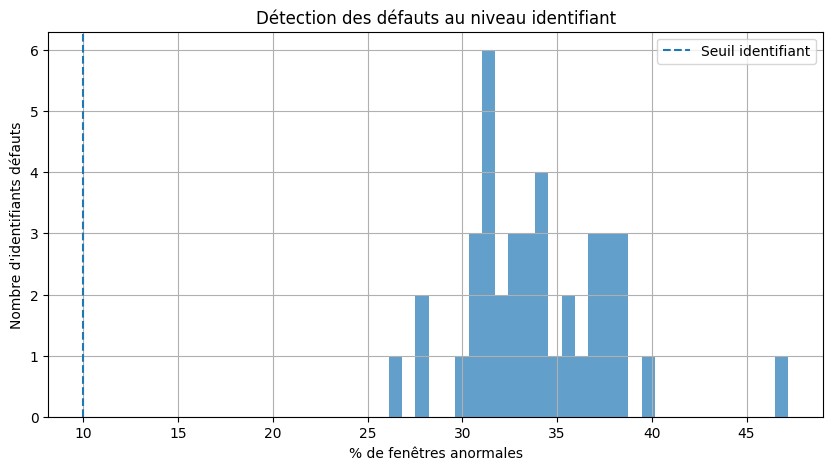

In [149]:
plt.figure(figsize=(10, 5))

plt.hist(
    summary_default["pct_windows_anormales"],
    bins=30,
    alpha=0.7
)

plt.axvline(
    seuil_id,
    linestyle="--",
    label="Seuil identifiant"
)

plt.xlabel("% de fenêtres anormales")
plt.ylabel("Nombre d'identifiants défauts")
plt.title("Détection des défauts au niveau identifiant")
plt.legend()
plt.grid()
plt.show()